<a href="https://colab.research.google.com/github/ArkanUbaidillah/DeepLearning_B_2411537001_ArkanUbaidillahWarman/blob/main/Praktikum1/DeepLearning_Praktikum_Minggu_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  PRAKTIKUM DEEP LEARNING - MINGGU 1
## Topik: Pengenalan Deep Learning dan Multilayer Perceptron (MLP)

Identitas Praktikan:
- Nama: Arkan Ubaidillah Warman
- NIM: 2411537001
- Kelas: B


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Load dataset
iris = load_iris()
X, y = iris.data, iris.target
X = StandardScaler().fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert ke tensor
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

In [14]:
# 3. Inisialisasi model
model = MLP(4, 3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [16]:
# 4. Training loop
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.2936
Epoch [20/100], Loss: 0.0912
Epoch [30/100], Loss: 0.0510
Epoch [40/100], Loss: 0.0408
Epoch [50/100], Loss: 0.0372
Epoch [60/100], Loss: 0.0343
Epoch [70/100], Loss: 0.0305
Epoch [80/100], Loss: 0.0257
Epoch [90/100], Loss: 0.0201
Epoch [100/100], Loss: 0.0144


In [18]:
# 5. Evaluasi
with torch.no_grad():
    y_pred = torch.argmax(model(X_test), dim=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAkurasi Model: {acc:.4f}")


Akurasi Model: 1.0000


In [19]:
# 5. Tugas Individu: Modifikasi Arsitektur Jaringan (128 - 64 - 32)
class MLPModified(nn.Module):
    def __init__(self, input_dim=4, output_dim=3):
        super(MLPModified, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# Inisialisasi model modifikasi
torch.manual_seed(42)
model_mod = MLPModified(input_dim=4, output_dim=3)
print(model_mod)

criterion_mod = nn.CrossEntropyLoss()
optimizer_mod = optim.Adam(model_mod.parameters(), lr=0.01)

loss_history_mod = []
start_time_mod = time.time()

for epoch in range(100):
    optimizer_mod.zero_grad()
    outputs_mod = model_mod(X_train)
    loss_mod = criterion_mod(outputs_mod, y_train)
    loss_mod.backward()
    optimizer_mod.step()

    loss_history_mod.append(loss_mod.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss_mod.item():.4f}")

time_mod = time.time() - start_time_mod
print(f"\nWaktu training model modifikasi: {time_mod:.4f} detik")

# Evaluasi model modifikasi
with torch.no_grad():
    y_pred_mod = torch.argmax(model_mod(X_test), dim=1)
    acc_mod = accuracy_score(y_test, y_pred_mod)
    print(f"\nAkurasi Model Modifikasi: {acc_mod:.4f}")
    print("\nLaporan Klasifikasi Modifikasi:")
    print(classification_report(y_test, y_pred_mod, target_names=iris.target_names))

MLPModified(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)
Epoch [10/100], Loss: 0.2174
Epoch [20/100], Loss: 0.0516
Epoch [30/100], Loss: 0.0356
Epoch [40/100], Loss: 0.0266
Epoch [50/100], Loss: 0.0159
Epoch [60/100], Loss: 0.0078
Epoch [70/100], Loss: 0.0032
Epoch [80/100], Loss: 0.0015
Epoch [90/100], Loss: 0.0008
Epoch [100/100], Loss: 0.0005

Waktu training model modifikasi: 0.1231 detik

Akurasi Model Modifikasi: 1.0000

Laporan Klasifikasi Modifikasi:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00    

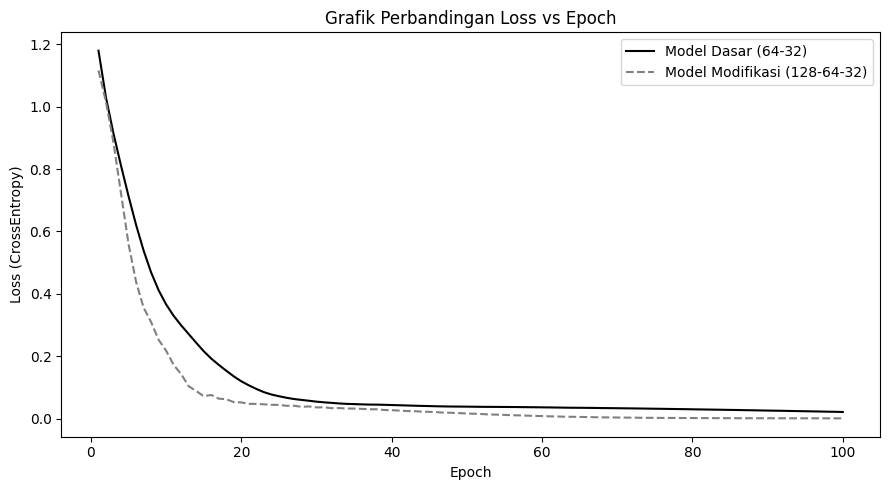

In [20]:
# 6. Visualisasi Grafik Loss vs Epoch (Grayscale / No Color)
plt.figure(figsize=(9, 5))
plt.plot(range(1, 101), loss_history_base, label='Model Dasar (64-32)', color='black', linestyle='-')
plt.plot(range(1, 101), loss_history_mod, label='Model Modifikasi (128-64-32)', color='gray', linestyle='--')
plt.title('Grafik Perbandingan Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.tight_layout()
plt.savefig('grafik_loss_vs_epoch.png', dpi=300)
plt.show()

In [21]:
# 7. Tabel Perbandingan Hasil Eksperimen
import pandas as pd

hasil_df = pd.DataFrame({
    'Parameter / Metrik': [
        'Arsitektur Hidden Layer',
        'Jumlah Parameter Dilatih',
        'Final Training Loss (Epoch 100)',
        'Waktu Pelatihan (detik)',
        'Akurasi Data Uji'
    ],
    'Model Dasar (Modul)': [
        '4 -> 64 -> 32 -> 3',
        '2,499',
        f'{loss_history_base[-1]:.4f}',
        f'{time_base:.4f} s',
        f'{acc_base * 100:.2f}%'
    ],
    'Model Modifikasi (Tugas)': [
        '4 -> 128 -> 64 -> 32 -> 3',
        '11,555',
        f'{loss_history_mod[-1]:.4f}',
        f'{time_mod:.4f} s',
        f'{acc_mod * 100:.2f}%'
    ]
})

print(hasil_df.to_string(index=False))

             Parameter / Metrik Model Dasar (Modul)  Model Modifikasi (Tugas)
        Arsitektur Hidden Layer  4 -> 64 -> 32 -> 3 4 -> 128 -> 64 -> 32 -> 3
       Jumlah Parameter Dilatih               2,499                    11,555
Final Training Loss (Epoch 100)              0.0209                    0.0005
        Waktu Pelatihan (detik)            0.3842 s                  0.1231 s
               Akurasi Data Uji             100.00%                   100.00%
